ANN classifier for classification of RNA-Seq of Tumor-Educated Platelets Enables Blood-Based Pan-Cancer, Multiclass, and Molecular Pathway Cancer Diagnostics.
Data can be accessed via this site: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE68086

Author: Nikolai Egorov

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer

# I. Load the dataset

In [ ]:
# Data can be found in the "data" folder.
data = pd.read_csv(f'data/GSE68086_TEP_data_matrix.txt', sep='\t', index_col=0)

# Table S1. Patient Characteristics
patient_training = pd.read_excel('data/1-s2.0-S1535610815003499-mmc2.xlsx', sheet_name='Training', header=3).iloc[:-11]
patient_validation = pd.read_excel('data/1-s2.0-S1535610815003499-mmc2.xlsx', sheet_name='Validation', header=3).iloc[:-11]

/opt/homebrew/Caskroom/miniconda/base/envs/mlails/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/Caskroom/miniconda/base/envs/mlails/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


# II. Inspect the data

In [3]:
patient_training

,Sample,Patient type,Gender,Age,Mutation,Metastasis,Organ of metastasis,Cancer treatment
0,HC-01,Healthy Donor (HD),M,53,-,-,-,-
1,HC-04,Healthy Donor (HD),F,64,-,-,-,-
2,HC-05,Healthy Donor (HD),F,64,-,-,-,-
3,HC-06,Healthy Donor (HD),M,41,-,-,-,-
4,HC-07,Healthy Donor (HD),M,49,-,-,-,-
...,...,...,...,...,...,...,...,...
170,Chol-379,Hepatobiliary carcinoma (HBC),F,75,KRAS WT,Y,"Lung, adrenal",CT
171,Chol-410,Hepatobiliary carcinoma (HBC),M,69,KRAS mut,Y,"Liver, pancreas","Surgery, CT"
172,Liver-274,Hepatobiliary carcinoma (HBC),M,48,KRAS WT,N,-,Surgery
173,Liver-366,Hepatobiliary carcinoma (HBC),M,64,KRAS WT,Y,Liver,CT


In [4]:
patient_validation

,Sample,Patient type,Gender,Age,Mutation,Metastasis,Organ of metastasis,Cancer treatment
0,HC-02,Healthy Donor (HD),F,53,-,-,-,-
1,HC-03,Healthy Donor (HD),F,53,-,-,-,-
2,HC-09,Healthy Donor (HD),M,44,-,-,-,-
3,HC-13,Healthy Donor (HD),F,26,-,-,-,-
4,HC-18,Healthy Donor (HD),F,22,-,-,-,-
...,...,...,...,...,...,...,...,...
103,Chol-442,Hepatobiliary carcinoma (HBC),M,72,KRAS WT,N,-,CT
104,Chol-460,Hepatobiliary carcinoma (HBC),F,81,KRAS WT,Y,"Lung, bone","CT, RT"
105,Chol-611,Hepatobiliary carcinoma (HBC),F,48,KRAS WT,Y,Liver,"CT, RT"
106,Chol-ALK-28,Hepatobiliary carcinoma (HBC),M,48,KRAS mut,Y,"Liver, peritoneal",CT


# III. Extract labels

Extract labels from the dataset to "feed" our model.


In [5]:
# Prepare Labels
patient_training['label'] = patient_training['Patient type'].str.split('(').str[1].str.split(')').str[0]
patient_validation['label'] = patient_validation['Patient type'].str.split(r'\(').str[1].str.split(r'\)').str[0]

labels = {sample: label for sample, label in zip(patient_training['Sample'], patient_training['label'])}
labels.update({sample: label for sample, label in zip(patient_validation['Sample'], patient_validation['label'])})


labels = data.columns.to_series().map(labels)
data_T = data.T

# IV. Label the data

In [6]:
# Prepare Labels using sample name rules
def map_label(sample):
    if 'HD' in sample:
        return 'HD'
    elif 'NSCLC' in sample or 'Lung' in sample:
        return 'NSCLC'
    elif 'CRC' in sample:
        return 'CRC'
    elif 'Pancr' in sample:
        return 'PAAD'
    elif 'GBM' in sample:
        return 'GBM'
    elif 'Breast' in sample or 'BrCa' in sample:
        return 'BrCa'
    elif 'HBC' in sample or 'Chol' in sample or 'Liver' in sample:
        return 'HBC'
    else:
        return 'Other'

data_T['label'] = data_T.index.map(map_label)
data_T['label_binary'] = np.where(data_T['label'] == 'HD', 'Healthy', 'Cancer')

# V. Binary Classification

In [7]:
# Train/Test Split
X_bin = data_T.drop(columns=['label_binary', 'label'])
y_bin = data_T['label_binary']
X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(X_bin, y_bin, stratify=y_bin, test_size=0.3, random_state=42)

Train Accuracy: 1.00, AUC: 1.00
Validation Accuracy: 0.91, AUC: 0.95


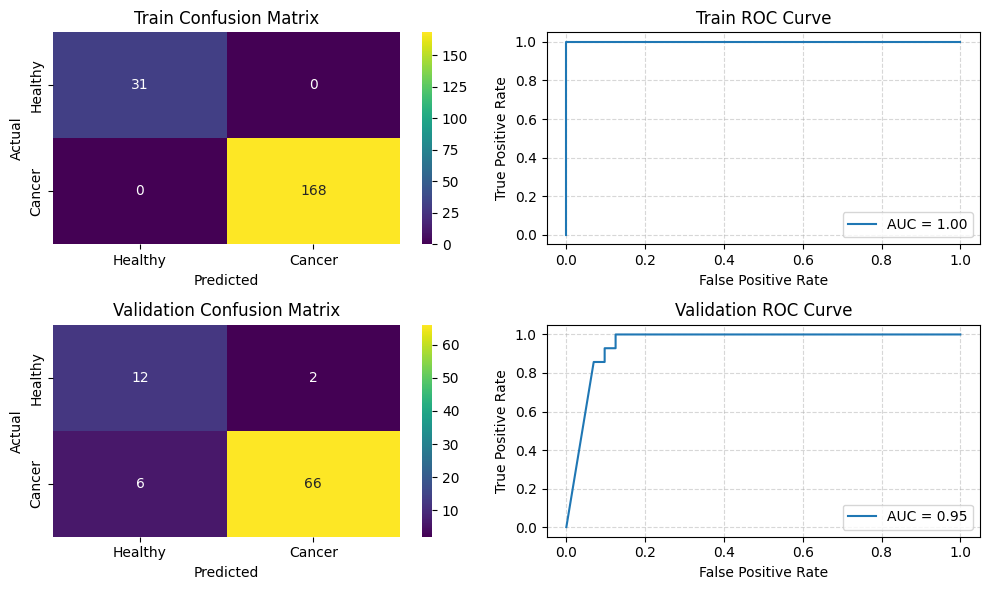

In [8]:
ann_bin = MLPClassifier(
            activation='relu',
            solver='adam',
            learning_rate_init=1e-3,
            hidden_layer_sizes=(50, 20),
            alpha=1e-4,
            max_iter=1000,
            random_state=42
            )

ann_bin.fit(X_train_bin, y_train_bin)
fig, axs = plt.subplots(2, 2, figsize=(10, 6))

# Predict and Evaluate
for i,(X, y, name) in enumerate([(X_train_bin, y_train_bin, 'Train'), (X_val_bin, y_val_bin, 'Validation')]):
    y_pred = ann_bin.predict(X)
    y_prob = ann_bin.predict_proba(X)[:, 1] if 'Healthy' in ann_bin.classes_ else ann_bin.predict_proba(X)[:, 0]
    cm = confusion_matrix(y, y_pred, labels=['Healthy', 'Cancer'])
    acc = accuracy_score(y, y_pred)
    fpr, tpr, _ = roc_curve((y == 'Healthy').astype(int), y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"{name} Accuracy: {acc:.2f}, AUC: {roc_auc:.2f}")

    # Plot Confusion Matrix and ROC Curve
    axs[i, 0].set_title(f'{name} Confusion Matrix')
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=axs[i, 0], xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    axs[i, 0].set_xlabel('Predicted')
    axs[i, 0].set_ylabel('Actual')

    axs[i, 1].set_title(f'{name} ROC Curve')
    axs[i, 1].plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    axs[i, 1].set_xlabel('False Positive Rate')
    axs[i, 1].set_ylabel('True Positive Rate')
    axs[i, 1].legend()
    axs[i,1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

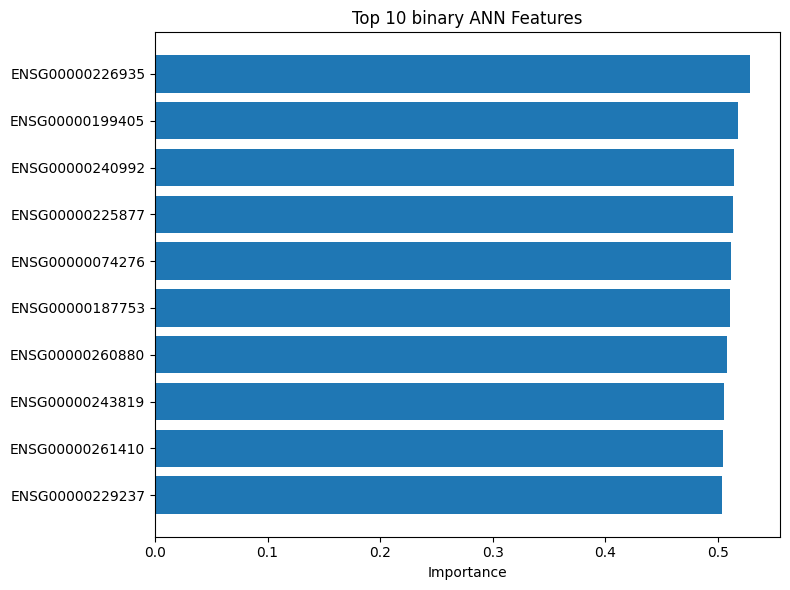

In [9]:
# 1) Grab the trained MLP object
mlp = ann_bin.named_steps['mlp'] if hasattr(ann_bin, 'named_steps') else ann_bin

# 2) Extract weights for two hidden layers + output
W0, W1, W2 = mlp.coefs_   # W0: (n_features×h1), W1: (h1×h2), W2: (h2×n_outputs)

# 3) Identify the “Cancer” output neuron
pos_idx = list(mlp.classes_).index('Cancer')

# 4) Compute the “weight-path” importance score
A = np.abs(W0).dot(np.abs(W1))                      # collapse to (n_features×h2)
importance = A.dot(np.abs(W2[:, pos_idx]))          # → (n_features,)

# 5) Select top 10
feat_names   = X_train_bin.columns
top10_idx    = np.argsort(importance)[::-1][:10]
top10_feats  = feat_names[top10_idx]
top10_scores = importance[top10_idx]

# 6) Plot horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(range(len(top10_feats))[::-1], top10_scores)
plt.yticks(range(len(top10_feats))[::-1], top10_feats)
plt.xlabel('Importance')
plt.title('Top 10 binary ANN Features')
plt.tight_layout()
plt.show()

# VI. Multi-class

In [10]:
classes = [sample for sample in data_T['label'].unique() if sample != 'Other']

multi_T = data_T[data_T['label'].isin(classes)]

min_count_multi = multi_T['label'].value_counts().min()
balanced_multi = multi_T.groupby('label').sample(n=min_count_multi, random_state=42)

# Train/Test Split
X_multi = balanced_multi.drop(columns=['label_binary', 'label'])
y_multi = balanced_multi['label']
X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(X_multi, y_multi, stratify=y_multi, test_size=0.3, random_state=42)

Train Accuracy (Multiclass): 0.84
Validation Accuracy (Multiclass): 0.31


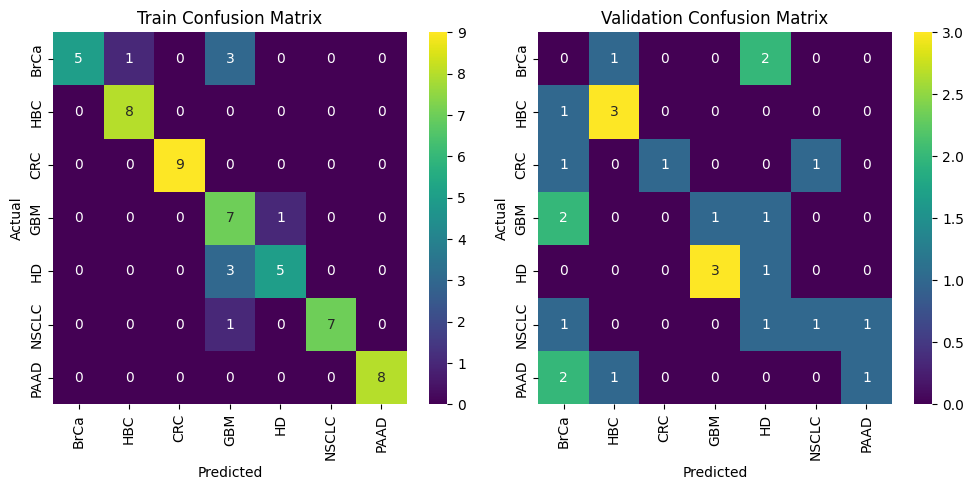

In [11]:
ann_multi = MLPClassifier(
    activation='relu',
    solver='adam',
    learning_rate_init=1e-3,
    hidden_layer_sizes=(50, 20),
    alpha=1e-4,
    max_iter=1000,
    random_state=42
)

ann_multi.fit(X_train_multi, y_train_multi)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Predict and Evaluate
for i,(X, y, name) in enumerate([(X_train_multi, y_train_multi, 'Train'), (X_val_multi, y_val_multi, 'Validation')]):
    y_pred = ann_multi.predict(X)
    acc = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred, labels=classes)

    # Plot Confusion Matrix and ROC Curve
    print(f"{name} Accuracy (Multiclass): {acc:.2f}")
    axs[i].set_title(f'{name} Confusion Matrix')
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=axs[i], xticklabels=classes, yticklabels=classes)
    axs[i].set_xlabel('Predicted')
    axs[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

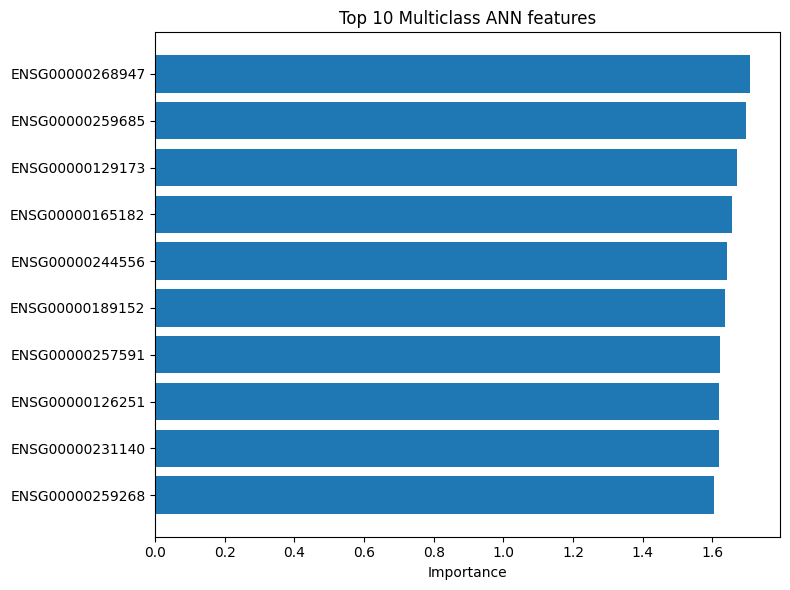

In [12]:
# 1) Grab the MLP
mlp = ann_multi.named_steps['mlp'] if hasattr(ann_multi, 'named_steps') else ann_multi

# 2) Get the 3 weight matrices W0→W1→W2
W0, W1, W2 = mlp.coefs_

# 3) Collapse through the two hidden layers
#    A: shape (n_features, n_hidden2)
A = np.abs(W0).dot(np.abs(W1))

# 4) Combine every output’s weights (here we sum absolute value across classes)
#    importance: shape (n_features,)
importance = A.dot(np.abs(W2)).sum(axis=1)

# 5) Pick top 10
feat_names   = X_train_multi.columns    # ← use the multiclass feature matrix
top10_idx    = np.argsort(importance)[::-1][:10]
top10_feats  = feat_names[top10_idx]
top10_scores = importance[top10_idx]

# 6) Plot
plt.figure(figsize=(8, 6))
plt.barh(range(len(top10_feats))[::-1], top10_scores)
plt.yticks(range(len(top10_feats))[::-1], top10_feats)
plt.xlabel('Importance')
plt.title('Top 10 Multiclass ANN features')
plt.tight_layout()
plt.show()